In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cloelite.input import reader
from cloelite.cosmology import camb_cosmology
from cloelite.observables import spectro
from copy import deepcopy

import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [2]:
reader_inst = reader.Reader('../../cloelite/input/parameters.yaml')
h = reader_inst.get_section('cosmology')['h']
H0 = h * 100.0
ombh2 = reader_inst.get_section('cosmology')['wb']
omch2 = reader_inst.get_section('cosmology')['wc']
ns = reader_inst.get_section('cosmology')['ns']
As = reader_inst.get_section('cosmology')['As']
background = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
linear_perturbations = camb_cosmology.CAMBLinearPerturbations(background=background, redshifts=np.linspace(0.0, 4.0, 256))
background_fiducial = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2*1.1, ns=ns, As=As, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
mps_spectro = spectro.LegendreMultipoles(NLcode='COMET', linear_perturbations=linear_perturbations, background_fiducial=background_fiducial)
mps_spectro.set_number_density(nbar=1e-4)

Note: redshifts have been re-sorted (earliest first)
Note: redshifts have been re-sorted (earliest first)


In [3]:
k = np.logspace(-3, np.log10(0.3), 100)
parameters = reader_inst.get_section('cosmology') | reader_inst.get_section('GCsp.theory') | reader_inst.get_section('GCsp.systematics')
parameters['As'] *= 1e9
parameters['z'] = 2.0

parameters_fid = deepcopy(parameters)
parameters_fid['wc'] = omch2*1.1
mps_spectro.set_fiducial_cosmology(parameters_fid)
mps_spectro.comet_inst.define_nbar(nbar=1e-4)
mps = mps_spectro.power_multipoles(k=k, parameters=parameters)

In [4]:
mps_1 = mps_spectro.power_multipoles_1(k=k, parameters=parameters, ells=[0,2,4], use_AP=True)

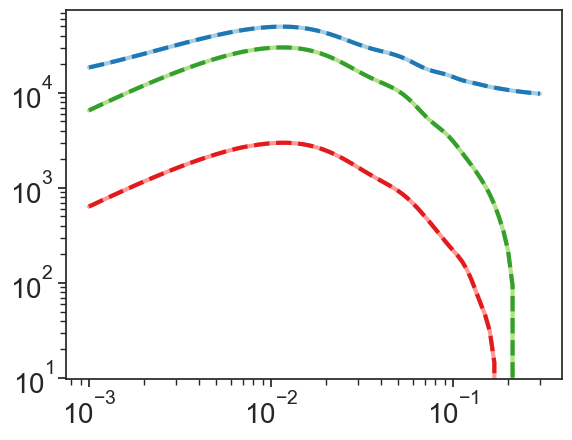

In [5]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

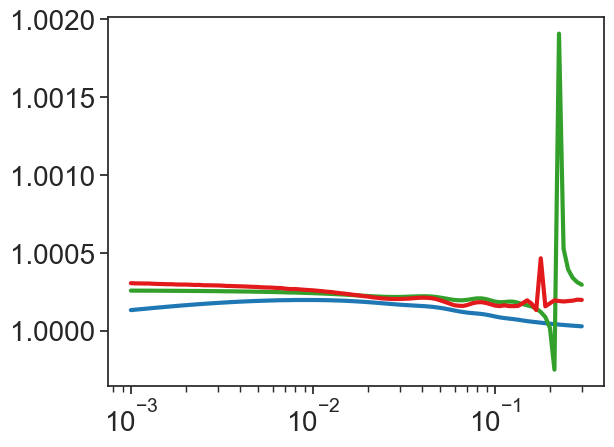

In [6]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [7]:
background = camb_cosmology.CAMBBackground(H0=H0, ombh2=ombh2, omch2=omch2, ns=ns, As=1e-9, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
linear_perturbations = camb_cosmology.CAMBLinearPerturbations(background=background, redshifts=np.linspace(0.0, 4.0, 256))
mps_spectro.update(linear_perturbations=linear_perturbations)
parameters['As'] = 1e-9 * 1e9

Note: redshifts have been re-sorted (earliest first)


In [8]:
mps = mps_spectro.power_multipoles(k=k, parameters=parameters)
mps_1 = mps_spectro.power_multipoles_1(k=k, parameters=parameters, ells=[0,2,4])

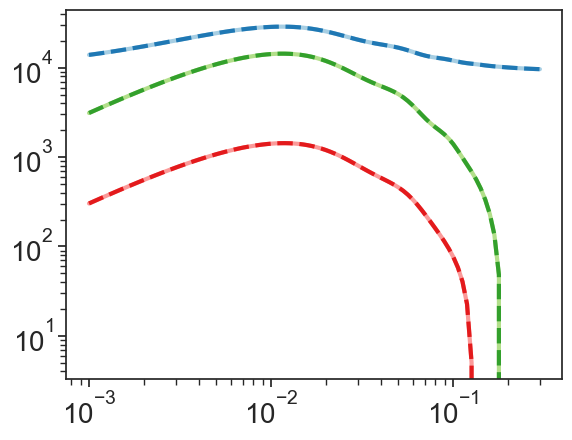

In [9]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

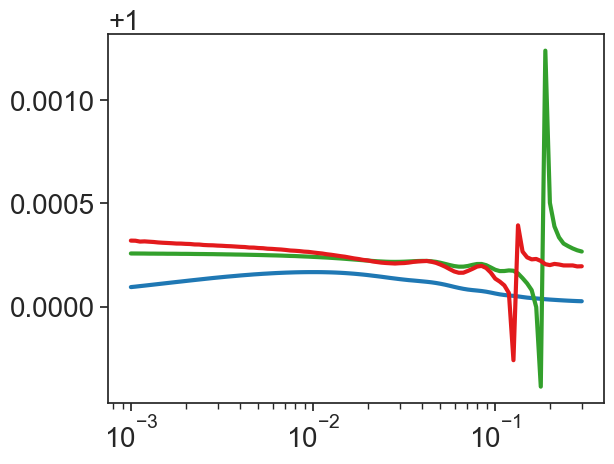

In [10]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [11]:
background = camb_cosmology.CAMBBackground(H0=90.0, ombh2=ombh2, omch2=omch2, ns=ns, As=2.1e-9, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
linear_perturbations = camb_cosmology.CAMBLinearPerturbations(background=background, redshifts=np.linspace(0.0, 4.0, 256))
mps_spectro.update(linear_perturbations=linear_perturbations)
parameters['As'] = 2.1e-9 * 1e9
parameters['h'] = 0.9

Note: redshifts have been re-sorted (earliest first)


In [12]:
mps = mps_spectro.power_multipoles(k=k, parameters=parameters)
mps_1 = mps_spectro.power_multipoles_1(k=k, parameters=parameters, ells=[0,2,4])

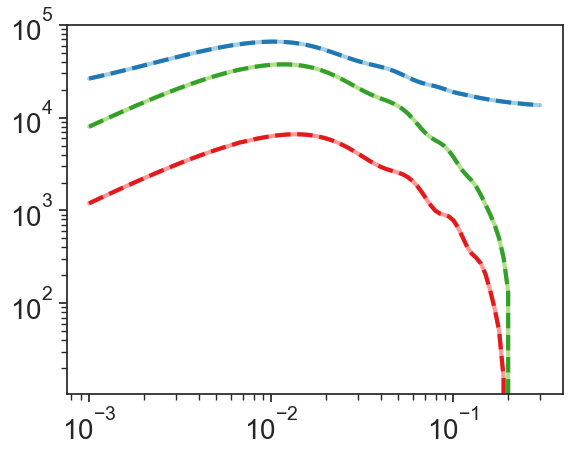

In [13]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

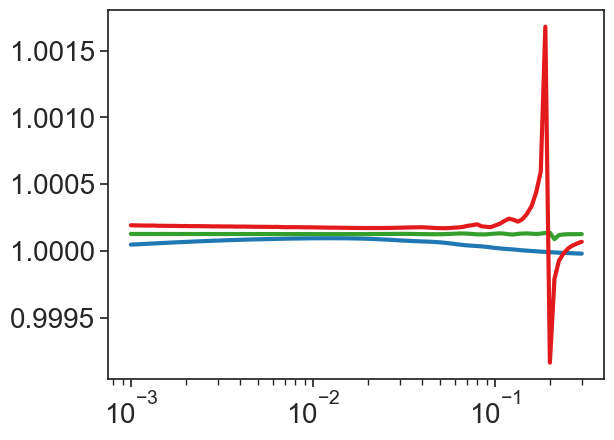

In [14]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])

In [15]:
background = camb_cosmology.CAMBBackground(H0=69.5, ombh2=ombh2, omch2=omch2, ns=ns, As=2.1e-9, w=-1.0, wa=0.0, Omk=0.0, sigma8=0.0, gamma_MG=0.0)
linear_perturbations = camb_cosmology.CAMBLinearPerturbations(background=background, redshifts=np.linspace(0.0, 4.0, 256))
mps_spectro.update(linear_perturbations=linear_perturbations)
parameters['As'] = 2.1e-9 * 1e9
parameters['h'] = 0.695

Note: redshifts have been re-sorted (earliest first)


In [16]:
mps = mps_spectro.power_multipoles(k=k, parameters=parameters)
mps_1 = mps_spectro.power_multipoles_1(k=k, parameters=parameters, ells=[0,2,4])

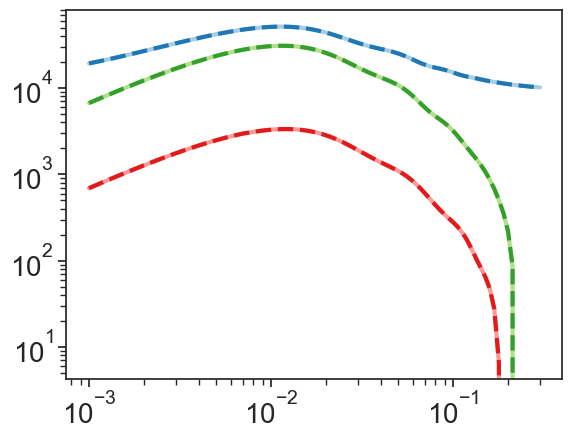

In [17]:
plt.loglog(k, mps['ell0'])
plt.loglog(k, mps_1['ell0'], ls='--')
plt.loglog(k, mps['ell2'])
plt.loglog(k, mps_1['ell2'], ls='--')
plt.loglog(k, mps['ell4'])
plt.loglog(k, mps_1['ell4'], ls='--')

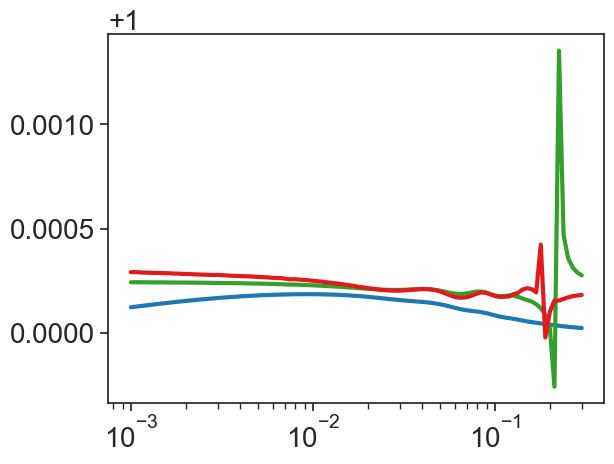

In [18]:
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell0']/mps['ell0'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell2']/mps['ell2'])
plt.semilogx([],[])
plt.semilogx(k, mps_1['ell4']/mps['ell4'])